    * Import main libararis

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import joblib

from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import chi2,f_classif
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder
from sklearn.metrics import f1_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

* `READ DATASET`

In [3]:
file_path = os.path.join(os.getcwd(), "..", "dataset", "Churn_Modelling.csv")
df = pd.read_csv(file_path)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\hp\\Desktop\\python projects\\churn-detection-project\\..\\dataset\\Churn_Modelling.csv'

In [ ]:
# Adjust col names
df.columns = df.columns.str.strip().str.replace(' ','_')

In [ ]:
# Drop first three columns
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace = True)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [ ]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


* `EDA`

In [ ]:
df.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [ ]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [ ]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [ ]:
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [ ]:
df["Tenure"].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

In [ ]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

* `Data Visualization & Handling Outliers`

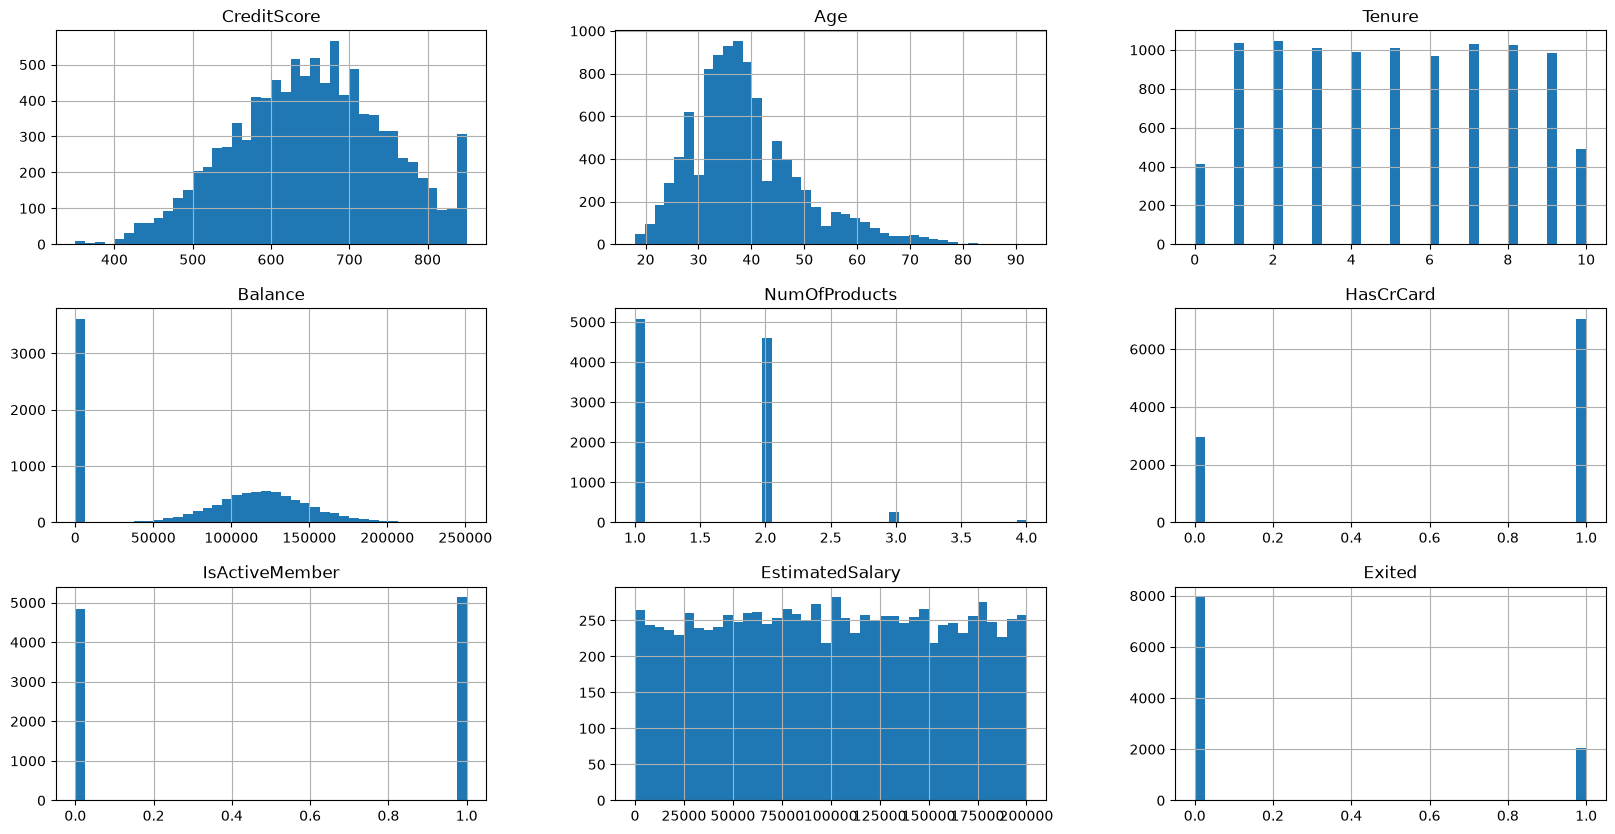

In [ ]:
df.hist(bins= 40,figsize=(20,10))
plt.show()

In [ ]:
df.drop(index=df[df["Age"] > 80].index.tolist(),inplace=True)

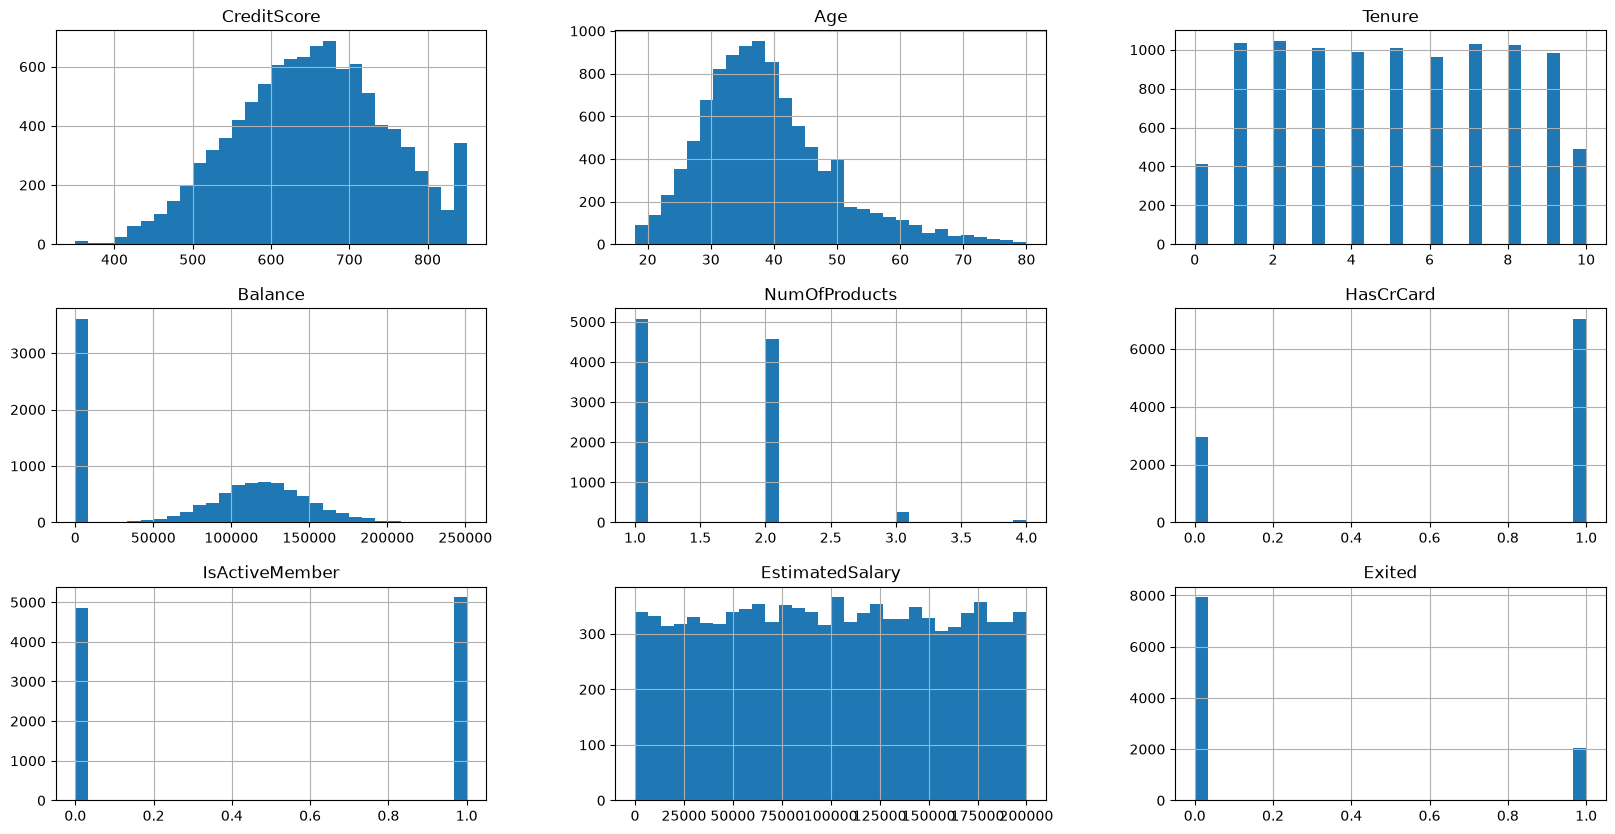

In [ ]:
## Numerical columns
df.hist(bins=30, figsize=(20, 10))
plt.show()

* `Split to train the Data Set`

In [ ]:
# to features and target
X = df.drop(columns=["Exited"])
y = df['Exited']

# to train and test
X_train,X_test,y_train,y_test =train_test_split(X , y , test_size=0.15 , random_state=42 , shuffle = True , stratify = y)

* `Feature Selection & Preprocessing`

In [ ]:
# slice columns
num_col = ["CreditScore", "Age", "Balance", "EstimatedSalary"]
cat_col = ["Geography", "Gender"]
ready_col = list(set(X_train.columns.tolist()) - set(num_col) - set(cat_col))

In [ ]:
# Numerical cols & Target cols --> Anova
_ , p_val = f_classif(X_train[num_col],y_train)
p_val

NameError: name 'f_classif' is not defined

In [ ]:
# Catigorical cols & Target cols --> chi2
_ , p_cal = chi2(OrdinalEncoder().fit_transform(X_train[cat_col]),y_train)
p_cal

array([7.98398152e-04, 1.13017659e-10])

In [ ]:
# Ready cols & Target cols --> chi2
_, p_ready = chi2(X_train[ready_col], y_train)
p_ready

array([3.16150229e-02, 2.41920541e-01, 2.51512485e-22, 7.41101791e-01])

In [ ]:
num_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaling',StandardScaler())
])

cat_pipline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("ohe", OneHotEncoder(sparse_output=False,drop='first'))]
)

ready_pipline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

preprocessor = ColumnTransformer(transformers = [
    ('numerical',num_pipline,num_col),
    ('categorical',cat_pipline,cat_col),
    ('ready',ready_pipline,ready_col)
])

# apply to train and test
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

* `Deal with imbalance dataset`

In [4]:
vals_count = 1 - np.bincount(y_train) / len(y_train)
vals_count = vals_count / sum(vals_count)

dic_weights = {}
for i in range(2):
    dic_weights[i] = vals_count[i]

print(dic_weights)

NameError: name 'y_train' is not defined

In [ ]:
over = SMOTE(k_neighbors = 5, sampling_strategy = 0.7,random_state = 42)
X_train_final_resample ,y_train_resample =over.fit_resample(X_train_final,y_train)

In [ ]:
MODEL_FOLDER_PATH = os.path.join(os.getcwd(),'..','models')
os.makedirs(MODEL_FOLDER_PATH,exist_ok=True)

In [ ]:
joblib.dump(preprocessor,os.path.join(MODEL_FOLDER_PATH,'preprocessor.pkl'))

['c:\\Users\\hp\\Desktop\\python projects\\churn-detection-project\\notebooks\\..\\models\\preprocessor.pkl']

* `Building Models`
    Let's consider the evaluation metric to  be f1_score

1.Using Logistic Regression

In [ ]:
log_clf = LogisticRegression(C = 1.5)
log_clf.fit(X_train_final,y_train)

y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

score_train_log = f1_score(y_train,y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f"The f1_score using Logistic model for Traning Dataset is {score_train_log}")
print(f"The f1_score using Logistic model for test Dataset is {score_test_log}")

The f1_score using Logistic model for Traning Dataset is 0.31337579617834393
The f1_score using Logistic model for test Dataset is 0.3682983682983683


In [ ]:
log_clf = LogisticRegression(C=1.5,class_weight=dic_weights)
log_clf.fit(X_train_final, y_train)

y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f"The f1_score using Logistic model for Traning Dataset is {score_train_log}")
print(f"The f1_score using Logistic model for test Dataset is {score_test_log}")


The f1_score using Logistic model for Traning Dataset is 0.49897076986414163
The f1_score using Logistic model for test Dataset is 0.4863582443653618


In [ ]:
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final_resample, y_train_resample)

y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f"The f1_score using Logistic model for Traning Dataset is {score_train_log}")
print(f"The f1_score using Logistic model for test Dataset is {score_test_log}")

The f1_score using Logistic model for Traning Dataset is 0.4982224479431183
The f1_score using Logistic model for test Dataset is 0.5007278020378457


<Axes: >

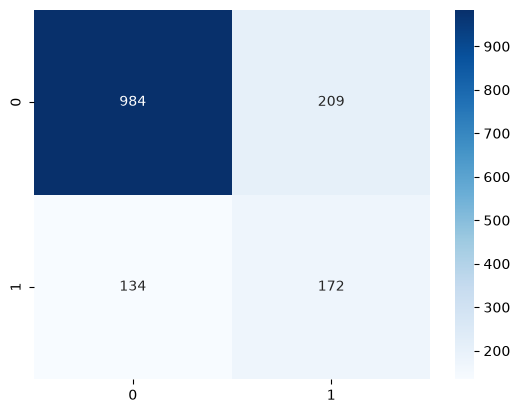

In [ ]:
sns.heatmap(confusion_matrix(y_true=y_test, y_pred=y_pred_test_log), cmap="Blues",annot= True,fmt='d')

In [ ]:
print(classification_report(y_true=y_test, y_pred=y_pred_test_log))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1193
           1       0.45      0.56      0.50       306

    accuracy                           0.77      1499
   macro avg       0.67      0.69      0.68      1499
weighted avg       0.79      0.77      0.78      1499



* `Random Forest Model`

In [ ]:
forest_clf = RandomForestClassifier(n_estimators = 150, max_depth= 5,random_state= 42,class_weight= dic_weights)
forest_clf.fit(X_train_final,y_train)

y_pred_train_forest = forest_clf.predict(X_train_final)
y_pred_test_forest = forest_clf.predict(X_test_final)

score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_forest)

print(f"The f1_score using Random Forest model for Traning Dataset is {score_train_forest}")
print(f"The f1_score using Random Forest model for test Dataset is {score_test_forest}")

The f1_score using Random Forest model for Traning Dataset is 0.6020174232003668
The f1_score using Random Forest model for test Dataset is 0.5951742627345844


In [ ]:
forest_clf = RandomForestClassifier(
    n_estimators=150, max_depth=5, random_state=42
)
forest_clf.fit(X_train_final_resample, y_train_resample)

y_pred_train_forest = forest_clf.predict(X_train_final)
y_pred_test_forest = forest_clf.predict(X_test_final)

score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_forest)

print(
    f"The f1_score using Random Forest model for Traning Dataset is {score_train_forest}"
)
print(f"The f1_score using Random Forest model for test Dataset is {score_test_forest}")


The f1_score using Random Forest model for Traning Dataset is 0.6142506142506142
The f1_score using Random Forest model for test Dataset is 0.6219081272084805


* `RF Tuning` 

In [ ]:
forest_base_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=42)

parms_best_grid = {
    "n_estimators":np.arange(50,400,50),
    "max_depth":np.arange(2,10,2)
}

grid_search_forest = GridSearchCV(estimator= forest_base_clf , param_grid = parms_best_grid , cv = 5 , n_jobs = -1 , verbose = 6 , scoring = 'f1')
grid_search_forest.fit(X_train_final,y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([2, 4, 6, 8]), 'n_estimators': array([ 50, 1...50, 300, 350])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digit

In [ ]:
grid_search_forest.best_params_

{'max_depth': np.int64(8), 'n_estimators': np.int64(100)}

In [ ]:
forest_tuned = grid_search_forest.best_estimator_

y_pred_train_forest_tuned = forest_tuned.predict(X_train_final)
y_pred_test_forest_tuned = forest_tuned.predict(X_test_final)

score_train_forest_tuned = f1_score(y_train, y_pred_train_forest_tuned)
score_test_forest_tuned = f1_score(y_test, y_pred_test_forest_tuned)

print(
    f"The f1_score using Random Forest model Tuned for Traning Dataset is {score_train_forest_tuned}"
)
print(
    f"The f1_score using Random Forest model Tuned for test Dataset is {score_test_forest_tuned}"
)


The f1_score using Random Forest model Tuned for Traning Dataset is 0.615210843373494
The f1_score using Random Forest model Tuned for test Dataset is 0.6198347107438017


In [ ]:
joblib.dump(forest_tuned,os.path.join(MODEL_FOLDER_PATH,'forest_tuned.pkl'))

['c:\\Users\\hp\\Desktop\\python projects\\churn-detection-project\\notebooks\\..\\models\\forest_tuned.pkl']

* `XGBoost`

In [ ]:
scale = (y_train == 0 ).sum() / (y_train == 1).sum()

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = class_weights / np.sum(class_weights)

weight_dic = dict(zip(np.unique(y_train), class_weights))

sample_weights = np.array([weight_dic[y] for y in y_train])

In [ ]:
xgb_base_clf = xgb.XGBClassifier(objective ='binary:logistic',max_depth = 5 ,learning_rate = 0.1, n_estimators = 150 , random_state = 42)

xgb_base_clf.fit(X_train_final,y_train)

y_pred_train_xgb = xgb_base_clf.predict(X_train_final)
y_pred_test_xgb = xgb_base_clf.predict(X_test_final)

score_train_xgb = f1_score(y_train, y_pred_train_xgb)
score_test_xgb = f1_score(y_test, y_pred_test_xgb)

print(f"The f1_score using XGBoost model for Traning Dataset is {score_train_xgb}")
print(f"The f1_score using XGBoost model for test Dataset is {score_test_xgb}")

The f1_score using XGBoost model for Traning Dataset is 0.6938349007314525
The f1_score using XGBoost model for test Dataset is 0.6232741617357002


In [ ]:
xgb_base_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    max_depth=5,
    learning_rate=0.1,
    n_estimators=150,
    random_state=42,
    reg_lambda = 5
)


In [ ]:
parms_best_xgb = {'max_depth':[3,4,5,6,7,8],
                  'learning_rate':[0.01,0.03,0.1,0.3],
                  'n_estimators':[100,200,300,400],
                  'min_child_weight':[1,3,5],
                  'subsample':[0.6,0.7,0.8,0.9],
                  'colsample_bytree':[0.6,0.7,0.8,0.9]}

random_search_xgb = RandomizedSearchCV(estimator=xgb_base_clf,param_distributions=parms_best_xgb,cv = 5,random_state = 42, verbose= 6 ,n_iter= 25,scoring='f1',n_jobs=-1)
random_search_xgb.fit(X_train_final,y_train,sample_weight = sample_weights)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",6
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function which

In [ ]:
random_search_xgb.best_params_

{'subsample': 0.8,
 'n_estimators': 100,
 'min_child_weight': 5,
 'max_depth': 6,
 'learning_rate': 0.03,
 'colsample_bytree': 0.6}

In [ ]:
xgb_tuned = random_search_xgb.best_estimator_

y_pred_train_xgb_tuned = xgb_tuned.predict(X_train_final)
y_pred_test_xgb_tuned = xgb_tuned.predict(X_test_final)

score_train_xgb_tuned = f1_score(y_train, y_pred_train_xgb_tuned)
score_test_xgb_tuned = f1_score(y_test, y_pred_test_xgb_tuned)

print(
    f"The f1_score using Tuned XGBoost model Tuned for Traning Dataset is {score_train_xgb_tuned}"
)
print(
    f"The f1_score using Tuned XGBoost model Tuned for test Dataset is {score_test_xgb_tuned}"
)


The f1_score using Tuned XGBoost model Tuned for Traning Dataset is 0.6373524647072437
The f1_score using Tuned XGBoost model Tuned for test Dataset is 0.6051560379918589


In [ ]:
joblib.dump(xgb_tuned,os.path.join(MODEL_FOLDER_PATH,'xgb_tuned.pkl'))

['c:\\Users\\hp\\Desktop\\python projects\\churn-detection-project\\notebooks\\..\\models\\xgb_tuned.pkl']